In [47]:
# Check existing SQL tables

cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""")

print("Tables currently in the database:")
for table in cursor.fetchall():
    print(table[0])

Tables currently in the database:
Patients
Appointments
Healthcare_Records


In [48]:
from google.colab import files

uploaded = files.upload()

Saving appointments_clean.csv to appointments_clean (2).csv
Saving healthcare_clean.csv to healthcare_clean (2).csv


In [49]:
import pandas as pd

healthcare = pd.read_csv("healthcare_clean.csv")
appointments = pd.read_csv("appointments_clean.csv")

print("Healthcare:", healthcare.shape)
print("Appointments:", appointments.shape)

Healthcare: (54966, 18)
Appointments: (110527, 15)


In [50]:
import sqlite3

conn = sqlite3.connect("healthcare_management.db")

print("SQLite database created successfully.")

SQLite database created successfully.


In [53]:
healthcare.to_sql(
    "healthcare_records",
    conn,
    if_exists="replace",
    index=False
)

appointments.to_sql(
    "appointments",
    conn,
    if_exists="replace",
    index=False
)

print("Both datasets loaded into SQL successfully.")

OperationalError: table "healthcare_records" already exists

In [54]:
cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table';
""")

print(cursor.fetchall())

[('Patients',), ('Appointments',), ('Healthcare_Records',)]


In [55]:
# Inspect healthcare table structure
print("=== HEALTHCARE RECORDS ===")

cursor.execute("PRAGMA table_info(healthcare_records);")

for column in cursor.fetchall():
    print(column)

print("\n=== APPOINTMENTS ===")

cursor.execute("PRAGMA table_info(appointments);")

for column in cursor.fetchall():
    print(column)

=== HEALTHCARE RECORDS ===
(0, 'Record_ID', 'INTEGER', 0, None, 1)
(1, 'Name', 'TEXT', 0, None, 0)
(2, 'Age', 'INTEGER', 0, None, 0)
(3, 'Gender', 'TEXT', 0, None, 0)
(4, 'Blood_Type', 'TEXT', 0, None, 0)
(5, 'Medical_Condition', 'TEXT', 0, None, 0)
(6, 'Date_of_Admission', 'TEXT', 0, None, 0)
(7, 'Doctor', 'TEXT', 0, None, 0)
(8, 'Hospital', 'TEXT', 0, None, 0)
(9, 'Insurance_Provider', 'TEXT', 0, None, 0)
(10, 'Billing_Amount', 'REAL', 0, None, 0)
(11, 'Room_Number', 'INTEGER', 0, None, 0)
(12, 'Admission_Type', 'TEXT', 0, None, 0)
(13, 'Discharge_Date', 'TEXT', 0, None, 0)
(14, 'Medication', 'TEXT', 0, None, 0)
(15, 'Test_Results', 'TEXT', 0, None, 0)
(16, 'Length_of_Stay', 'INTEGER', 0, None, 0)

=== APPOINTMENTS ===
(0, 'AppointmentID', 'INTEGER', 0, None, 1)
(1, 'PatientID', 'TEXT', 1, None, 0)
(2, 'ScheduledDay', 'TEXT', 0, None, 0)
(3, 'AppointmentDay', 'TEXT', 0, None, 0)
(4, 'Age', 'REAL', 0, None, 0)
(5, 'Waiting_Days', 'REAL', 0, None, 0)
(6, 'SMS_received', 'INTEGER', 0, N

In [56]:
print("=== HEALTHCARE DATA ===")

print("Total records:", len(healthcare))

print("Unique Names:", healthcare["Name"].nunique())
print("Unique Doctors:", healthcare["Doctor"].nunique())
print("Unique Hospitals:", healthcare["Hospital"].nunique())
print("Unique Insurance Providers:", healthcare["Insurance Provider"].nunique())
print("Unique Medical Conditions:", healthcare["Medical Condition"].nunique())


print("\n=== APPOINTMENT DATA ===")

print("Total appointments:", len(appointments))

print("Unique Patient IDs:", appointments["PatientId"].nunique())
print("Unique Appointment IDs:", appointments["AppointmentID"].nunique())

=== HEALTHCARE DATA ===
Total records: 54966
Unique Names: 49992
Unique Doctors: 40341
Unique Hospitals: 39876
Unique Insurance Providers: 5
Unique Medical Conditions: 6

=== APPOINTMENT DATA ===
Total appointments: 110527
Unique Patient IDs: 62299
Unique Appointment IDs: 110527


In [57]:
patient_appointment_counts = (
    appointments.groupby("PatientId")["AppointmentID"]
    .count()
    .sort_values(ascending=False)
)

print("Maximum appointments for one patient:",
      patient_appointment_counts.max())

print("\nTop 10 patients by number of appointments:")
print(patient_appointment_counts.head(10))

Maximum appointments for one patient: 88

Top 10 patients by number of appointments:
PatientId
8.221459e+14    88
9.963767e+10    84
2.688613e+13    70
3.353478e+13    65
7.579746e+13    62
6.264199e+12    62
8.713749e+14    62
2.584244e+11    62
6.684488e+13    57
8.722785e+11    55
Name: AppointmentID, dtype: int64


In [58]:
# Convert PatientId to string so it is treated as an identifier
appointments["PatientId"] = appointments["PatientId"].apply(
    lambda x: str(int(x)) if pd.notna(x) else None
)

print(appointments["PatientId"].head())
print("\nData type:", appointments["PatientId"].dtype)

0     29872499824296
1    558997776694438
2      4262962299951
3       867951213174
4      8841186448183
Name: PatientId, dtype: object

Data type: object


In [59]:
print("Unique Patient IDs:", appointments["PatientId"].nunique())
print("Total appointments:", len(appointments))

Unique Patient IDs: 62299
Total appointments: 110527


In [60]:
# Create the Patients table data
patients = (
    appointments[
        [
            "PatientId",
            "Gender",
            "Age",
            "Neighbourhood",
            "Scholarship",
            "Hipertension",
            "Diabetes",
            "Alcoholism",
            "Handcap"
        ]
    ]
    .drop_duplicates(subset=["PatientId"])
    .copy()
)

print("Patients:", len(patients))
print("Unique Patient IDs:", patients["PatientId"].nunique())

display(patients.head())

Patients: 62299
Unique Patient IDs: 62299


,PatientId,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap
0,29872499824296,F,62.0,JARDIM DA PENHA,0,1,0,0,0
1,558997776694438,M,56.0,JARDIM DA PENHA,0,0,0,0,0
2,4262962299951,F,62.0,MATA DA PRAIA,0,0,0,0,0
3,867951213174,F,8.0,PONTAL DE CAMBURI,0,0,0,0,0
4,8841186448183,F,56.0,JARDIM DA PENHA,0,1,1,0,0


In [61]:
# Check whether patient information is consistent across appointments

profile_columns = [
    "Gender",
    "Age",
    "Neighbourhood",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap"
]

for col in profile_columns:
    inconsistent = (
        appointments.groupby("PatientId")[col]
        .nunique(dropna=True)
    )

    inconsistent_count = (inconsistent > 1).sum()

    print(f"{col}: {inconsistent_count} patients have multiple values")

Gender: 0 patients have multiple values
Age: 1168 patients have multiple values
Neighbourhood: 0 patients have multiple values
Scholarship: 0 patients have multiple values
Hipertension: 0 patients have multiple values
Diabetes: 0 patients have multiple values
Alcoholism: 0 patients have multiple values
Handcap: 0 patients have multiple values


In [62]:
print("Missing Patient IDs:",
      appointments["PatientId"].isna().sum())

print("Missing Appointment IDs:",
      appointments["AppointmentID"].isna().sum())

Missing Patient IDs: 0
Missing Appointment IDs: 0


In [63]:
# Enable foreign key enforcement in SQLite
conn.execute("PRAGMA foreign_keys = ON")

# Remove old tables if they exist
conn.execute("DROP TABLE IF EXISTS Appointments")
conn.execute("DROP TABLE IF EXISTS Patients")

# Create Patients table
conn.execute("""
CREATE TABLE Patients (
    PatientID TEXT PRIMARY KEY,
    Gender TEXT,
    Neighbourhood TEXT,
    Scholarship INTEGER,
    Hypertension INTEGER,
    Diabetes INTEGER,
    Alcoholism INTEGER,
    Handicap INTEGER
)
""")

# Create Appointments table
conn.execute("""
CREATE TABLE Appointments (
    AppointmentID INTEGER PRIMARY KEY,
    PatientID TEXT NOT NULL,
    ScheduledDay TEXT,
    AppointmentDay TEXT,
    Age REAL,
    Waiting_Days REAL,
    SMS_received INTEGER,
    No_show TEXT,

    FOREIGN KEY (PatientID)
        REFERENCES Patients(PatientID)
)
""")

conn.commit()

print("Patients and Appointments tables created successfully.")

Patients and Appointments tables created successfully.


In [64]:
# Prepare patient data
patients_sql = patients[
    [
        "PatientId",
        "Gender",
        "Neighbourhood",
        "Scholarship",
        "Hipertension",
        "Diabetes",
        "Alcoholism",
        "Handcap"
    ]
].copy()

patients_sql.columns = [
    "PatientID",
    "Gender",
    "Neighbourhood",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap"
]

# Load Patients
patients_sql.to_sql(
    "Patients",
    conn,
    if_exists="append",
    index=False
)

# Prepare appointment data
appointments_sql = appointments[
    [
        "AppointmentID",
        "PatientId",
        "ScheduledDay",
        "AppointmentDay",
        "Age",
        "Waiting_Days",
        "SMS_received",
        "No-show"
    ]
].copy()

appointments_sql.columns = [
    "AppointmentID",
    "PatientID",
    "ScheduledDay",
    "AppointmentDay",
    "Age",
    "Waiting_Days",
    "SMS_received",
    "No_show"
]

# Load Appointments
appointments_sql.to_sql(
    "Appointments",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("Data loaded successfully.")

Data loaded successfully.


In [65]:
# Check row counts

print("Patients:",
      conn.execute("SELECT COUNT(*) FROM Patients").fetchone()[0])

print("Appointments:",
      conn.execute("SELECT COUNT(*) FROM Appointments").fetchone()[0])

Patients: 62299
Appointments: 110527


In [66]:
# Check for appointments whose PatientID does not exist
# in the Patients table

orphan_appointments = conn.execute("""
SELECT COUNT(*)
FROM Appointments a
LEFT JOIN Patients p
    ON a.PatientID = p.PatientID
WHERE p.PatientID IS NULL
""").fetchone()[0]

print("Appointments with missing patient:", orphan_appointments)

Appointments with missing patient: 0


In [67]:
print("Healthcare records:", len(healthcare))

print("\nBilling validation:")
print(healthcare[["Billing Amount", "Billing_Valid", "Valid_Billing"]].head(10))

print("\nLength of stay:")
print(healthcare["Length_of_Stay"].describe())

Healthcare records: 54966

Billing validation:
   Billing Amount  Billing_Valid  Valid_Billing
0    18856.281306   18856.281306   18856.281306
1    33643.327287   33643.327287   33643.327287
2    27955.096079   27955.096079   27955.096079
3    37909.782410   37909.782410   37909.782410
4    14238.317814   14238.317814   14238.317814
5    48145.110951   48145.110951   48145.110951
6    19580.872345   19580.872345   19580.872345
7    45820.462722   45820.462722   45820.462722
8    50119.222792   50119.222792   50119.222792
9    19784.631062   19784.631062   19784.631062

Length of stay:
count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length_of_Stay, dtype: float64


In [68]:
# Create a unique ID for each healthcare record

healthcare["Record_ID"] = range(1, len(healthcare) + 1)

print("Total healthcare records:", len(healthcare))
print("Unique Record IDs:", healthcare["Record_ID"].nunique())
print("Missing Record IDs:", healthcare["Record_ID"].isna().sum())

Total healthcare records: 54966
Unique Record IDs: 54966
Missing Record IDs: 0


In [69]:
# Create Healthcare_Records table

conn.execute("DROP TABLE IF EXISTS Healthcare_Records")

conn.execute("""
CREATE TABLE Healthcare_Records (
    Record_ID INTEGER PRIMARY KEY,
    Name TEXT,
    Age INTEGER,
    Gender TEXT,
    Blood_Type TEXT,
    Medical_Condition TEXT,
    Date_of_Admission TEXT,
    Doctor TEXT,
    Hospital TEXT,
    Insurance_Provider TEXT,
    Billing_Amount REAL,
    Room_Number INTEGER,
    Admission_Type TEXT,
    Discharge_Date TEXT,
    Medication TEXT,
    Test_Results TEXT,
    Length_of_Stay INTEGER
)
""")

conn.commit()

print("Healthcare_Records table created successfully.")

Healthcare_Records table created successfully.


In [70]:
# Prepare healthcare data for SQL

healthcare_sql = healthcare[
    [
        "Record_ID",
        "Name",
        "Age",
        "Gender",
        "Blood Type",
        "Medical Condition",
        "Date of Admission",
        "Doctor",
        "Hospital",
        "Insurance Provider",
        "Billing Amount",
        "Room Number",
        "Admission Type",
        "Discharge Date",
        "Medication",
        "Test Results",
        "Length_of_Stay"
    ]
].copy()

# Rename columns to SQL-friendly names
healthcare_sql.columns = [
    "Record_ID",
    "Name",
    "Age",
    "Gender",
    "Blood_Type",
    "Medical_Condition",
    "Date_of_Admission",
    "Doctor",
    "Hospital",
    "Insurance_Provider",
    "Billing_Amount",
    "Room_Number",
    "Admission_Type",
    "Discharge_Date",
    "Medication",
    "Test_Results",
    "Length_of_Stay"
]

# Load into SQL table
healthcare_sql.to_sql(
    "Healthcare_Records",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("Healthcare data loaded successfully.")

Healthcare data loaded successfully.


In [71]:
print(
    "Healthcare records in SQL:",
    conn.execute("SELECT COUNT(*) FROM Healthcare_Records").fetchone()[0]
)

Healthcare records in SQL: 54966


In [72]:
# Final database verification

tables = ["Patients", "Appointments", "Healthcare_Records"]

for table in tables:
    count = conn.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]

    print(f"{table}: {count:,} rows")

Patients: 62,299 rows
Appointments: 110,527 rows
Healthcare_Records: 54,966 rows


In [73]:
# ==========================================
# STEP 1: BASIC APPOINTMENT OVERVIEW
# ==========================================

query = """
SELECT
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END) AS no_shows,
    SUM(CASE WHEN No_show = 'No' THEN 1 ELSE 0 END) AS attended,
    ROUND(
        100.0 * SUM(CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS no_show_rate
FROM Appointments;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_appointments,no_shows,attended,no_show_rate
0,110527,22319,88208,20.19


In [74]:
# ==========================================
# STEP 2: NO-SHOW ANALYSIS BY GENDER
# ==========================================

query = """
SELECT
    p.Gender,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN a.No_show = 'Yes' THEN 1 ELSE 0 END) AS no_shows,
    SUM(CASE WHEN a.No_show = 'No' THEN 1 ELSE 0 END) AS attended,
    ROUND(
        100.0 * SUM(CASE WHEN a.No_show = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS no_show_rate
FROM Appointments a
JOIN Patients p
    ON a.PatientID = p.PatientID
GROUP BY p.Gender
ORDER BY no_show_rate DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Gender,total_appointments,no_shows,attended,no_show_rate
0,F,71840,14594,57246,20.31
1,M,38687,7725,30962,19.97


In [75]:
# Check the actual columns in the Patients table

cursor = conn.cursor()

cursor.execute("PRAGMA table_info(Patients);")

for column in cursor.fetchall():
    print(column)

(0, 'PatientID', 'TEXT', 0, None, 1)
(1, 'Gender', 'TEXT', 0, None, 0)
(2, 'Neighbourhood', 'TEXT', 0, None, 0)
(3, 'Scholarship', 'INTEGER', 0, None, 0)
(4, 'Hypertension', 'INTEGER', 0, None, 0)
(5, 'Diabetes', 'INTEGER', 0, None, 0)
(6, 'Alcoholism', 'INTEGER', 0, None, 0)
(7, 'Handicap', 'INTEGER', 0, None, 0)


In [76]:
# ==========================================
# STEP 3: NO-SHOW ANALYSIS BY AGE GROUP
# ==========================================

query = """
SELECT
    CASE
        WHEN a.Age < 18 THEN 'Under 18'
        WHEN a.Age BETWEEN 18 AND 30 THEN '18-30'
        WHEN a.Age BETWEEN 31 AND 45 THEN '31-45'
        WHEN a.Age BETWEEN 46 AND 60 THEN '46-60'
        ELSE '61+'
    END AS age_group,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN a.No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN a.No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN a.No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments a

GROUP BY age_group

ORDER BY no_show_rate DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,age_group,total_appointments,no_shows,attended,no_show_rate
0,18-30,18252,4493,13759,24.62
1,Under 18,27379,5997,21382,21.90
2,31-45,21954,4692,17262,21.37
3,46-60,23179,4131,19048,17.82
4,61+,19763,3006,16757,15.21


In [77]:
# ==========================================
# STEP 4: SMS REMINDER VS NO-SHOW
# ==========================================

query = """
SELECT
    SMS_received,
    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY SMS_received

ORDER BY SMS_received;
"""

result = pd.read_sql_query(query, conn)

display(result)

,SMS_received,total_appointments,no_shows,attended,no_show_rate
0,0,75045,12535,62510,16.70
1,1,35482,9784,25698,27.57


In [78]:
# ==========================================
# STEP 5: NO-SHOW BY WAITING TIME
# ==========================================

query = """
SELECT
    CASE
        WHEN Waiting_Days = 0 THEN 'Same day'
        WHEN Waiting_Days BETWEEN 1 AND 7 THEN '1-7 days'
        WHEN Waiting_Days BETWEEN 8 AND 30 THEN '8-30 days'
        WHEN Waiting_Days BETWEEN 31 AND 60 THEN '31-60 days'
        ELSE '61+ days'
    END AS waiting_group,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY waiting_group

ORDER BY no_show_rate DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,waiting_group,total_appointments,no_shows,attended,no_show_rate
0,31-60 days,8283,2829,5454,34.15
1,8-30 days,29396,9325,20071,31.72
2,61+ days,2100,601,1499,28.62
3,1-7 days,32185,7772,24413,24.15
4,Same day,38563,1792,36771,4.65


In [79]:
# ==========================================
# STEP 6: NO-SHOW ANALYSIS BY NEIGHBOURHOOD
# ==========================================

query = """
SELECT
    p.Neighbourhood,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN a.No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN a.No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN a.No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments a

JOIN Patients p
    ON a.PatientID = p.PatientID

GROUP BY p.Neighbourhood

ORDER BY total_appointments DESC;
"""

result = pd.read_sql_query(query, conn)

display(result.head(20))

,Neighbourhood,total_appointments,no_shows,attended,no_show_rate
0,JARDIM CAMBURI,7717,1465,6252,18.98
1,MARIA ORTIZ,5805,1219,4586,21.00
2,RESISTÊNCIA,4431,906,3525,20.45
3,JARDIM DA PENHA,3877,631,3246,16.28
4,ITARARÉ,3514,923,2591,26.27
5,CENTRO,3334,703,2631,21.09
6,TABUAZEIRO,3132,573,2559,18.30
7,SANTA MARTHA,3131,496,2635,15.84
8,JESUS DE NAZARETH,2853,696,2157,24.40
9,BONFIM,2773,550,2223,19.83


In [80]:
# ==========================================
# STEP 7: NO-SHOW ANALYSIS BY SMS REMINDER
# ==========================================

query = """
SELECT
    CASE
        WHEN SMS_received = 0 THEN 'No SMS'
        WHEN SMS_received = 1 THEN 'SMS received'
    END AS sms_status,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY SMS_received

ORDER BY SMS_received;
"""

result = pd.read_sql_query(query, conn)

display(result)

,sms_status,total_appointments,no_shows,attended,no_show_rate
0,No SMS,75045,12535,62510,16.70
1,SMS received,35482,9784,25698,27.57


In [81]:
# ==========================================
# STEP 8: WAITING TIME + SMS ANALYSIS
# ==========================================

query = """
SELECT
    CASE
        WHEN Waiting_Days = 0 THEN 'Same day'
        WHEN Waiting_Days BETWEEN 1 AND 7 THEN '1-7 days'
        WHEN Waiting_Days BETWEEN 8 AND 30 THEN '8-30 days'
        WHEN Waiting_Days BETWEEN 31 AND 60 THEN '31-60 days'
        ELSE '61+ days'
    END AS waiting_group,

    CASE
        WHEN SMS_received = 0 THEN 'No SMS'
        WHEN SMS_received = 1 THEN 'SMS received'
    END AS sms_status,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY waiting_group, SMS_received

ORDER BY waiting_group, SMS_received;
"""

result = pd.read_sql_query(query, conn)

display(result)

,waiting_group,sms_status,total_appointments,no_shows,attended,no_show_rate
0,1-7 days,No SMS,20637,5028,15609,24.36
1,1-7 days,SMS received,11548,2744,8804,23.76
2,31-60 days,No SMS,3224,1237,1987,38.37
3,31-60 days,SMS received,5059,1592,3467,31.47
4,61+ days,No SMS,749,257,492,34.31
5,61+ days,SMS received,1351,344,1007,25.46
6,8-30 days,No SMS,11872,4221,7651,35.55
7,8-30 days,SMS received,17524,5104,12420,29.13
8,Same day,No SMS,38563,1792,36771,4.65


In [82]:
# ==========================================
# STEP 9: PATIENT APPOINTMENT & NO-SHOW ANALYSIS
# ==========================================

query = """
SELECT
    PatientID,
    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY PatientID

HAVING COUNT(*) >= 5

ORDER BY no_show_rate DESC, total_appointments DESC

LIMIT 20;
"""

result = pd.read_sql_query(query, conn)

display(result)

,PatientID,total_appointments,no_shows,attended,no_show_rate
0,1421986987763,18,18,0,100.0
1,563513528548171,16,16,0,100.0
2,581197334462339,14,14,0,100.0
3,65751443779385,13,13,0,100.0
4,93388598973955,10,10,0,100.0
5,46836777451462,9,9,0,100.0
6,216298164113,8,8,0,100.0
7,28516799229,7,7,0,100.0
8,34849787522388,7,7,0,100.0
9,1144471549922,6,6,0,100.0


In [83]:
# ==========================================
# STEP 10: PATIENTS WITH MIXED ATTENDANCE
# ==========================================

query = """
SELECT
    PatientID,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY PatientID

HAVING COUNT(*) >= 5
   AND SUM(CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END) > 0
   AND SUM(CASE WHEN No_show = 'No' THEN 1 ELSE 0 END) > 0

ORDER BY no_show_rate DESC

LIMIT 20;
"""

result = pd.read_sql_query(query, conn)

display(result)

,PatientID,total_appointments,no_shows,attended,no_show_rate
0,476861615941,12,11,1,91.67
1,818266813128899,9,8,1,88.89
2,338493115647194,9,8,1,88.89
3,843842591341772,8,7,1,87.50
4,43633912482343,8,7,1,87.50
5,88788112249921,7,6,1,85.71
6,82791222257,7,6,1,85.71
7,631384515483,7,6,1,85.71
8,52812262369945,7,6,1,85.71
9,48324575874555,7,6,1,85.71


In [84]:
# ==========================================
# STEP 11: MONTHLY APPOINTMENT ANALYSIS
# ==========================================

query = """
SELECT
    strftime('%Y-%m', ScheduledDay) AS month,

    COUNT(*) AS total_appointments,

    SUM(
        CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
    ) AS no_shows,

    SUM(
        CASE WHEN No_show = 'No' THEN 1 ELSE 0 END
    ) AS attended,

    ROUND(
        100.0 * SUM(
            CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END
        ) / COUNT(*),
        2
    ) AS no_show_rate

FROM Appointments

GROUP BY month

ORDER BY month;
"""

result = pd.read_sql_query(query, conn)

display(result)

,month,total_appointments,no_shows,attended,no_show_rate
0,2015-11,1,0,1,0.00
1,2015-12,61,19,42,31.15
2,2016-01,60,18,42,30.00
3,2016-02,281,82,199,29.18
4,2016-03,3614,1196,2418,33.09
5,2016-04,25339,7849,17490,30.98
6,2016-05,67421,11769,55652,17.46
7,2016-06,13750,1386,12364,10.08


In [86]:
# ==========================================
# STEP 12: HOSPITAL ANALYSIS
# ==========================================

query = """
SELECT
    Hospital,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Hospital
ORDER BY total_records DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Hospital,total_records,average_billing,total_billing
0,LLC Smith,44,23413.41,1030189.87
1,Ltd Smith,39,25727.32,1003365.53
2,Smith Ltd,37,26217.19,970035.87
3,Johnson PLC,37,29229.12,1081477.31
4,Smith PLC,36,28595.12,1029424.45
...,...,...,...,...
39871,"Abbott, Vazquez Bautista and",1,14117.14,14117.14
39872,"Abbott and Thompson, Sullivan",1,16738.57,16738.57
39873,"Abbott Moore and Williams,",1,24799.60,24799.60
39874,Abbott Ltd,1,29877.59,29877.59


In [88]:
# ==========================================
# STEP 13: INSURANCE PROVIDER ANALYSIS
# ==========================================

query = """
SELECT
    Insurance_Provider,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing

FROM Healthcare_Records

GROUP BY Insurance_Provider

ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,total_records,average_billing,total_billing
0,Cigna,11139,25526.00,2.843341e+08
1,Medicare,11039,25628.32,2.829110e+08
2,Blue Cross,10952,25603.46,2.804091e+08
3,UnitedHealthcare,11014,25414.51,2.799154e+08
4,Aetna,10822,25549.69,2.764987e+08


In [89]:
# ==========================================
# STEP 14: BILLING BY MEDICAL CONDITION
# ==========================================

query = """
SELECT
    Medical_Condition,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing

FROM Healthcare_Records

GROUP BY Medical_Condition

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,total_records,average_billing,total_billing
0,Obesity,9146,25804.36,2.360067e+08
1,Diabetes,9216,25660.48,2.364870e+08
2,Asthma,9095,25633.46,2.331363e+08
3,Arthritis,9218,25511.78,2.351676e+08
4,Hypertension,9151,25503.06,2.333785e+08
5,Cancer,9140,25152.32,2.298922e+08


In [90]:
# ==========================================
# STEP 15: BILLING BY ADMISSION TYPE
# ==========================================

query = """
SELECT
    Admission_Type,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing

FROM Healthcare_Records

GROUP BY Admission_Type

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Admission_Type,total_records,average_billing,total_billing
0,Elective,18473,25612.14,4.731331e+08
1,Urgent,18391,25514.53,4.692378e+08
2,Emergency,18102,25505.33,4.616975e+08


In [91]:
# ==========================================
# STEP 16: USING HAVING
# ==========================================

query = """
SELECT
    Medical_Condition,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing

FROM Healthcare_Records

GROUP BY Medical_Condition

HAVING COUNT(*) > 9150

ORDER BY total_records DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,total_records,average_billing
0,Arthritis,9218,25511.78
1,Diabetes,9216,25660.48
2,Hypertension,9151,25503.06


In [92]:
# ==========================================
# STEP 17: SUBQUERY
# ==========================================

query = """
SELECT
    Medical_Condition,
    ROUND(AVG(Billing_Amount), 2) AS average_billing

FROM Healthcare_Records

GROUP BY Medical_Condition

HAVING AVG(Billing_Amount) > (
    SELECT AVG(Billing_Amount)
    FROM Healthcare_Records
)

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing
0,Obesity,25804.36
1,Diabetes,25660.48
2,Asthma,25633.46


In [93]:
# ==========================================
# STEP 18: CTE
# ==========================================

query = """
WITH condition_billing AS (
    SELECT
        Medical_Condition,
        COUNT(*) AS total_records,
        ROUND(SUM(Billing_Amount), 2) AS total_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
)

SELECT
    Medical_Condition,
    total_records,
    total_billing

FROM condition_billing

WHERE total_billing > 230000000

ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,total_records,total_billing
0,Diabetes,9216,2.364870e+08
1,Obesity,9146,2.360067e+08
2,Arthritis,9218,2.351676e+08
3,Hypertension,9151,2.333785e+08
4,Asthma,9095,2.331363e+08


In [94]:
# ==========================================
# STEP 19: WINDOW FUNCTION - RANK
# ==========================================

query = """
SELECT
    Medical_Condition,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,

    RANK() OVER (
        ORDER BY AVG(Billing_Amount) DESC
    ) AS billing_rank

FROM Healthcare_Records

GROUP BY Medical_Condition

ORDER BY billing_rank;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,total_records,average_billing,billing_rank
0,Obesity,9146,25804.36,1
1,Diabetes,9216,25660.48,2
2,Asthma,9095,25633.46,3
3,Arthritis,9218,25511.78,4
4,Hypertension,9151,25503.06,5
5,Cancer,9140,25152.32,6


In [95]:
# ==========================================
# STEP 20: ROW_NUMBER() VS RANK()
# ==========================================

query = """
SELECT
    Medical_Condition,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,

    ROW_NUMBER() OVER (
        ORDER BY AVG(Billing_Amount) DESC
    ) AS row_number,

    RANK() OVER (
        ORDER BY AVG(Billing_Amount) DESC
    ) AS rank_number

FROM Healthcare_Records

GROUP BY Medical_Condition

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing,row_number,rank_number
0,Obesity,25804.36,1,1
1,Diabetes,25660.48,2,2
2,Asthma,25633.46,3,3
3,Arthritis,25511.78,4,4
4,Hypertension,25503.06,5,5
5,Cancer,25152.32,6,6


In [96]:
# ==========================================
# STEP 21: LAG() AND LEAD()
# ==========================================

query = """
WITH condition_billing AS (
    SELECT
        Medical_Condition,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
)

SELECT
    Medical_Condition,
    average_billing,

    LAG(average_billing) OVER (
        ORDER BY average_billing DESC
    ) AS previous_billing,

    LEAD(average_billing) OVER (
        ORDER BY average_billing DESC
    ) AS next_billing

FROM condition_billing

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing,previous_billing,next_billing
0,Obesity,25804.36,NaN,25660.48
1,Diabetes,25660.48,25804.36,25633.46
2,Asthma,25633.46,25660.48,25511.78
3,Arthritis,25511.78,25633.46,25503.06
4,Hypertension,25503.06,25511.78,25152.32
5,Cancer,25152.32,25503.06,NaN


In [97]:
# ==========================================
# STEP 22: BILLING DIFFERENCE USING LAG()
# ==========================================

query = """
WITH condition_billing AS (
    SELECT
        Medical_Condition,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
),

billing_comparison AS (
    SELECT
        Medical_Condition,
        average_billing,
        LAG(average_billing) OVER (
            ORDER BY average_billing DESC
        ) AS previous_billing
    FROM condition_billing
)

SELECT
    Medical_Condition,
    average_billing,
    previous_billing,
    ROUND(
        previous_billing - average_billing, 2
    ) AS billing_difference

FROM billing_comparison

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing,previous_billing,billing_difference
0,Obesity,25804.36,NaN,NaN
1,Diabetes,25660.48,25804.36,143.88
2,Asthma,25633.46,25660.48,27.02
3,Arthritis,25511.78,25633.46,121.68
4,Hypertension,25503.06,25511.78,8.72
5,Cancer,25152.32,25503.06,350.74


In [98]:
# ==========================================
# STEP 23: RUNNING TOTAL
# ==========================================

query = """
WITH condition_billing AS (
    SELECT
        Medical_Condition,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
)

SELECT
    Medical_Condition,
    average_billing,

    ROUND(
        SUM(average_billing) OVER (
            ORDER BY average_billing DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ), 2
    ) AS running_total

FROM condition_billing

ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing,running_total
0,Obesity,25804.36,25804.36
1,Diabetes,25660.48,51464.84
2,Asthma,25633.46,77098.30
3,Arthritis,25511.78,102610.08
4,Hypertension,25503.06,128113.14
5,Cancer,25152.32,153265.46


In [99]:
# ==========================================
# STEP 24: PERCENTAGE CONTRIBUTION
# ==========================================

query = """
WITH condition_billing AS (
    SELECT
        Medical_Condition,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
)

SELECT
    Medical_Condition,
    average_billing,

    ROUND(
        100.0 * average_billing /
        SUM(average_billing) OVER (),
        2
    ) AS percentage_of_total

FROM condition_billing

ORDER BY percentage_of_total DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing,percentage_of_total
0,Obesity,25804.36,16.84
1,Diabetes,25660.48,16.74
2,Asthma,25633.46,16.72
3,Arthritis,25511.78,16.65
4,Hypertension,25503.06,16.64
5,Cancer,25152.32,16.41


In [100]:
# ==========================================
# STEP 25: CONDITION VS OVERALL AVERAGE
# ==========================================

query = """
WITH condition_billing AS (
    SELECT
        Medical_Condition,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
)

SELECT
    Medical_Condition,
    average_billing,

    RANK() OVER (
        ORDER BY average_billing DESC
    ) AS billing_rank,

    ROUND(
        average_billing -
        AVG(average_billing) OVER (),
        2
    ) AS difference_from_overall_avg

FROM condition_billing

ORDER BY billing_rank;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,average_billing,billing_rank,difference_from_overall_avg
0,Obesity,25804.36,1,260.12
1,Diabetes,25660.48,2,116.24
2,Asthma,25633.46,3,89.22
3,Arthritis,25511.78,4,-32.46
4,Hypertension,25503.06,5,-41.18
5,Cancer,25152.32,6,-391.92


In [101]:
# ==========================================
# STEP 26: PROJECT KPI SUMMARY
# ==========================================

query = """
SELECT
    COUNT(*) AS total_records,
    ROUND(SUM(Billing_Amount), 2) AS total_billing,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    COUNT(DISTINCT Medical_Condition) AS medical_conditions,
    COUNT(DISTINCT Insurance_Provider) AS insurance_providers
FROM Healthcare_Records;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_records,total_billing,average_billing,medical_conditions,insurance_providers
0,54966,1.404068e+09,25544.31,6,5


In [102]:
# ==========================================
# STEP 27: INSURANCE PROVIDER ANALYSIS
# ==========================================

query = """
SELECT
    Insurance_Provider,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Insurance_Provider
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,total_records,average_billing,total_billing
0,Cigna,11139,25526.00,2.843341e+08
1,Medicare,11039,25628.32,2.829110e+08
2,Blue Cross,10952,25603.46,2.804091e+08
3,UnitedHealthcare,11014,25414.51,2.799154e+08
4,Aetna,10822,25549.69,2.764987e+08


In [103]:
# ==========================================
# STEP 28: INSURANCE PROVIDER RANKING
# ==========================================

query = """
WITH provider_summary AS (
    SELECT
        Insurance_Provider,
        COUNT(*) AS total_records,
        ROUND(AVG(Billing_Amount), 2) AS average_billing,
        ROUND(SUM(Billing_Amount), 2) AS total_billing
    FROM Healthcare_Records
    GROUP BY Insurance_Provider
)

SELECT
    Insurance_Provider,
    total_records,
    average_billing,
    total_billing,
    RANK() OVER (
        ORDER BY total_billing DESC
    ) AS billing_rank
FROM provider_summary
ORDER BY billing_rank;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,total_records,average_billing,total_billing,billing_rank
0,Cigna,11139,25526.00,2.843341e+08,1
1,Medicare,11039,25628.32,2.829110e+08,2
2,Blue Cross,10952,25603.46,2.804091e+08,3
3,UnitedHealthcare,11014,25414.51,2.799154e+08,4
4,Aetna,10822,25549.69,2.764987e+08,5


In [104]:
# ==========================================
# STEP 29: PROVIDER VS OVERALL AVERAGE
# ==========================================

query = """
WITH provider_summary AS (
    SELECT
        Insurance_Provider,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Insurance_Provider
),

overall_average AS (
    SELECT
        ROUND(AVG(Billing_Amount), 2) AS overall_avg
    FROM Healthcare_Records
)

SELECT
    p.Insurance_Provider,
    p.average_billing,
    o.overall_avg,
    ROUND(p.average_billing - o.overall_avg, 2) AS difference_from_overall
FROM provider_summary p
CROSS JOIN overall_average o
ORDER BY difference_from_overall DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,average_billing,overall_avg,difference_from_overall
0,Medicare,25628.32,25544.31,84.01
1,Blue Cross,25603.46,25544.31,59.15
2,Aetna,25549.69,25544.31,5.38
3,Cigna,25526.00,25544.31,-18.31
4,UnitedHealthcare,25414.51,25544.31,-129.80


In [105]:
# ==========================================
# STEP 30: RANK CONDITIONS WITHIN ADMISSION TYPE
# ==========================================

query = """
WITH condition_summary AS (
    SELECT
        Admission_Type,
        Medical_Condition,
        COUNT(*) AS total_records,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Admission_Type, Medical_Condition
)

SELECT
    Admission_Type,
    Medical_Condition,
    total_records,
    average_billing,
    RANK() OVER (
        PARTITION BY Admission_Type
        ORDER BY average_billing DESC
    ) AS billing_rank
FROM condition_summary
ORDER BY Admission_Type, billing_rank;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Admission_Type,Medical_Condition,total_records,average_billing,billing_rank
0,Elective,Diabetes,3031,26032.12,1
1,Elective,Obesity,3015,25687.73,2
2,Elective,Cancer,3114,25671.84,3
3,Elective,Hypertension,3182,25555.09,4
4,Elective,Arthritis,3062,25479.59,5
5,Elective,Asthma,3069,25253.91,6
6,Emergency,Asthma,2978,25893.70,1
7,Emergency,Obesity,3100,25820.55,2
8,Emergency,Arthritis,3073,25497.11,3
9,Emergency,Diabetes,2988,25471.61,4


In [106]:
# ==========================================
# FINAL QUERY 1: OVERALL PROJECT KPI SUMMARY
# ==========================================

query = """
SELECT
    COUNT(*) AS total_records,
    COUNT(DISTINCT Medical_Condition) AS medical_conditions,
    COUNT(DISTINCT Insurance_Provider) AS insurance_providers,
    ROUND(SUM(Billing_Amount), 2) AS total_billing,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(MIN(Billing_Amount), 2) AS minimum_billing,
    ROUND(MAX(Billing_Amount), 2) AS maximum_billing
FROM Healthcare_Records;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_records,medical_conditions,insurance_providers,total_billing,average_billing,minimum_billing,maximum_billing
0,54966,6,5,1.404068e+09,25544.31,-2008.49,52764.28


In [107]:
# ==========================================
# FINAL QUERY 2: MEDICAL CONDITION SUMMARY
# ==========================================

query = """
SELECT
    Medical_Condition,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Medical_Condition
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,total_records,average_billing,total_billing
0,Diabetes,9216,25660.48,2.364870e+08
1,Obesity,9146,25804.36,2.360067e+08
2,Arthritis,9218,25511.78,2.351676e+08
3,Hypertension,9151,25503.06,2.333785e+08
4,Asthma,9095,25633.46,2.331363e+08
5,Cancer,9140,25152.32,2.298922e+08


In [108]:
# ==========================================
# FINAL QUERY 3: INSURANCE PROVIDER SUMMARY
# ==========================================

query = """
SELECT
    Insurance_Provider,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Insurance_Provider
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,total_records,average_billing,total_billing
0,Cigna,11139,25526.00,2.843341e+08
1,Medicare,11039,25628.32,2.829110e+08
2,Blue Cross,10952,25603.46,2.804091e+08
3,UnitedHealthcare,11014,25414.51,2.799154e+08
4,Aetna,10822,25549.69,2.764987e+08


In [109]:
# ==========================================
# FINAL QUERY 4: ADMISSION TYPE SUMMARY
# ==========================================

query = """
SELECT
    Admission_Type,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Admission_Type
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Admission_Type,total_records,average_billing,total_billing
0,Elective,18473,25612.14,4.731331e+08
1,Urgent,18391,25514.53,4.692378e+08
2,Emergency,18102,25505.33,4.616975e+08


In [111]:
# ==========================================
# FINAL QUERY 5: HIGHEST BILLING RECORDS
# ==========================================

query = """
SELECT
    Medical_Condition,
    Insurance_Provider,
    Admission_Type,
    Billing_Amount
FROM Healthcare_Records
ORDER BY Billing_Amount DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Medical_Condition,Insurance_Provider,Admission_Type,Billing_Amount
0,Hypertension,Blue Cross,Elective,52764.276736
1,Cancer,UnitedHealthcare,Urgent,52373.032374
2,Cancer,UnitedHealthcare,Urgent,52373.032374
3,Hypertension,Blue Cross,Emergency,52271.663747
4,Diabetes,Aetna,Urgent,52211.852966
5,Asthma,Aetna,Emergency,52181.837792
6,Arthritis,Cigna,Urgent,52170.036854
7,Arthritis,Cigna,Urgent,52170.036854
8,Cancer,UnitedHealthcare,Urgent,52154.237722
9,Cancer,Cigna,Emergency,52102.240889


In [112]:
# ==========================================
# FINAL QUERY 6: CONDITION + ADMISSION ANALYSIS
# ==========================================

query = """
SELECT
    Admission_Type,
    Medical_Condition,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Admission_Type, Medical_Condition
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Admission_Type,Medical_Condition,total_records,average_billing,total_billing
0,Urgent,Diabetes,3197,25484.65,81474429.35
1,Elective,Hypertension,3182,25555.09,81316292.67
2,Emergency,Obesity,3100,25820.55,80043716.31
3,Elective,Cancer,3114,25671.84,79942117.82
4,Elective,Diabetes,3031,26032.12,78903370.57
5,Urgent,Arthritis,3083,25558.38,78796495.26
6,Urgent,Asthma,3048,25761.37,78520649.82
7,Urgent,Obesity,3031,25903.82,78514463.64
8,Emergency,Arthritis,3073,25497.11,78352604.61
9,Elective,Arthritis,3062,25479.59,78018518.10


,Medical_Condition,total_billing
0,Diabetes,2.364870e+08
1,Obesity,2.360067e+08
2,Arthritis,2.351676e+08
3,Hypertension,2.333785e+08
4,Asthma,2.331363e+08
5,Cancer,2.298922e+08


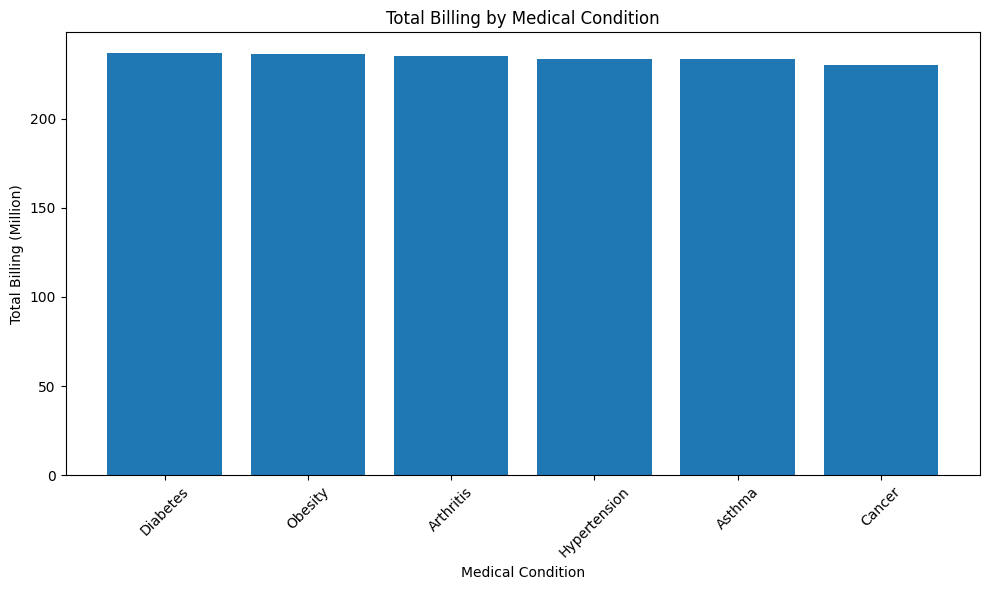

In [113]:
# ==========================================
# STEP 31: TOTAL BILLING BY MEDICAL CONDITION
# ==========================================

query = """
SELECT
    Medical_Condition,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Medical_Condition
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    result["Medical_Condition"],
    result["total_billing"] / 1e6
)

plt.xlabel("Medical Condition")
plt.ylabel("Total Billing (Million)")
plt.title("Total Billing by Medical Condition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Medical_Condition,average_billing
0,Obesity,25804.36
1,Diabetes,25660.48
2,Asthma,25633.46
3,Arthritis,25511.78
4,Hypertension,25503.06
5,Cancer,25152.32


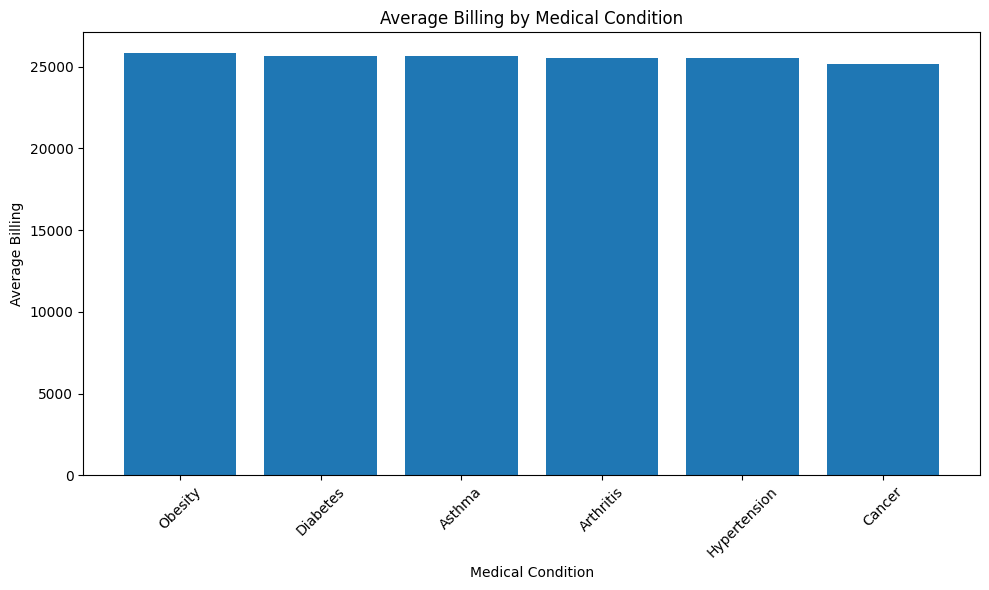

In [114]:
# ==========================================
# STEP 32: AVERAGE BILLING BY MEDICAL CONDITION
# ==========================================

query = """
SELECT
    Medical_Condition,
    ROUND(AVG(Billing_Amount), 2) AS average_billing
FROM Healthcare_Records
GROUP BY Medical_Condition
ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    result["Medical_Condition"],
    result["average_billing"]
)

plt.xlabel("Medical Condition")
plt.ylabel("Average Billing")
plt.title("Average Billing by Medical Condition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Insurance_Provider,total_billing
0,Cigna,2.843341e+08
1,Medicare,2.829110e+08
2,Blue Cross,2.804091e+08
3,UnitedHealthcare,2.799154e+08
4,Aetna,2.764987e+08


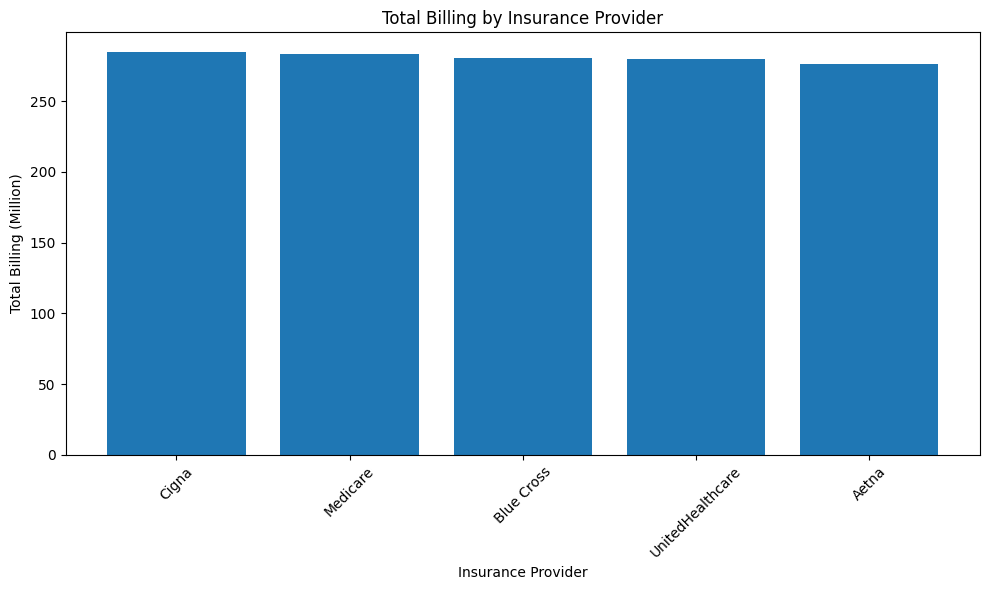

In [115]:
# ==========================================
# STEP 33: TOTAL BILLING BY INSURANCE PROVIDER
# ==========================================

query = """
SELECT
    Insurance_Provider,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Insurance_Provider
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    result["Insurance_Provider"],
    result["total_billing"] / 1e6
)

plt.xlabel("Insurance Provider")
plt.ylabel("Total Billing (Million)")
plt.title("Total Billing by Insurance Provider")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Admission_Type,total_billing
0,Elective,4.731331e+08
1,Urgent,4.692378e+08
2,Emergency,4.616975e+08


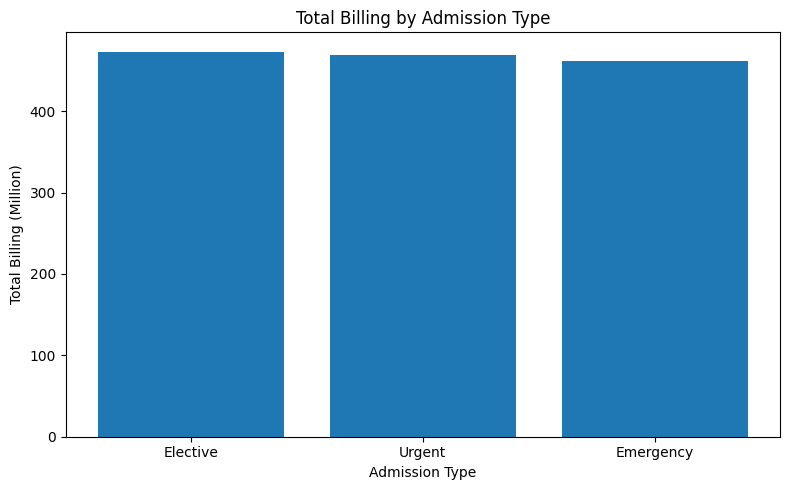

In [116]:
# ==========================================
# STEP 34: TOTAL BILLING BY ADMISSION TYPE
# ==========================================

query = """
SELECT
    Admission_Type,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Admission_Type
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    result["Admission_Type"],
    result["total_billing"] / 1e6
)

plt.xlabel("Admission Type")
plt.ylabel("Total Billing (Million)")
plt.title("Total Billing by Admission Type")
plt.tight_layout()
plt.show()

,Admission_Type,total_records,average_billing
0,Elective,18473,25612.14
1,Urgent,18391,25514.53
2,Emergency,18102,25505.33


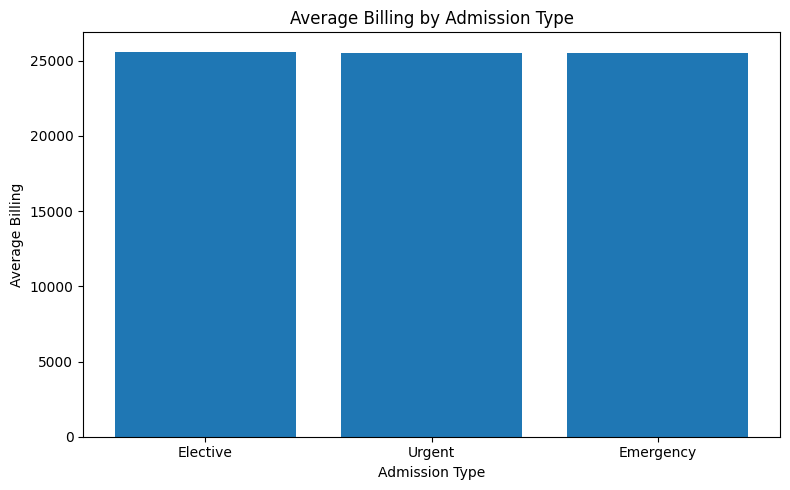

In [117]:
# ==========================================
# STEP 35: AVERAGE BILLING BY ADMISSION TYPE
# ==========================================

query = """
SELECT
    Admission_Type,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing
FROM Healthcare_Records
GROUP BY Admission_Type
ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    result["Admission_Type"],
    result["average_billing"]
)

plt.xlabel("Admission Type")
plt.ylabel("Average Billing")
plt.title("Average Billing by Admission Type")
plt.tight_layout()
plt.show()

,Medical_Condition,Insurance_Provider,Admission_Type,Billing_Amount
0,Hypertension,Blue Cross,Elective,52764.276736
1,Cancer,UnitedHealthcare,Urgent,52373.032374
2,Cancer,UnitedHealthcare,Urgent,52373.032374
3,Hypertension,Blue Cross,Emergency,52271.663747
4,Diabetes,Aetna,Urgent,52211.852966
5,Asthma,Aetna,Emergency,52181.837792
6,Arthritis,Cigna,Urgent,52170.036854
7,Arthritis,Cigna,Urgent,52170.036854
8,Cancer,UnitedHealthcare,Urgent,52154.237722
9,Cancer,Cigna,Emergency,52102.240889


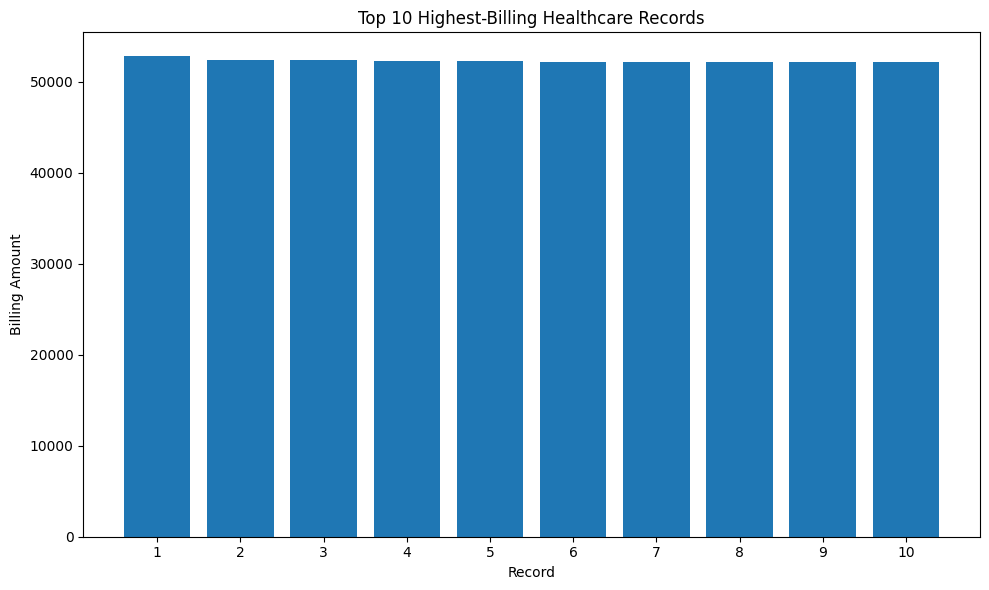

In [118]:
# ==========================================
# STEP 36: TOP 10 HIGHEST-BILLING RECORDS
# ==========================================

query = """
SELECT
    Medical_Condition,
    Insurance_Provider,
    Admission_Type,
    Billing_Amount
FROM Healthcare_Records
ORDER BY Billing_Amount DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
plt.figure(figsize=(10, 6))

plt.bar(
    range(len(result)),
    result["Billing_Amount"]
)

plt.xlabel("Record")
plt.ylabel("Billing Amount")
plt.title("Top 10 Highest-Billing Healthcare Records")
plt.xticks(range(len(result)), range(1, 11))

plt.tight_layout()
plt.show()

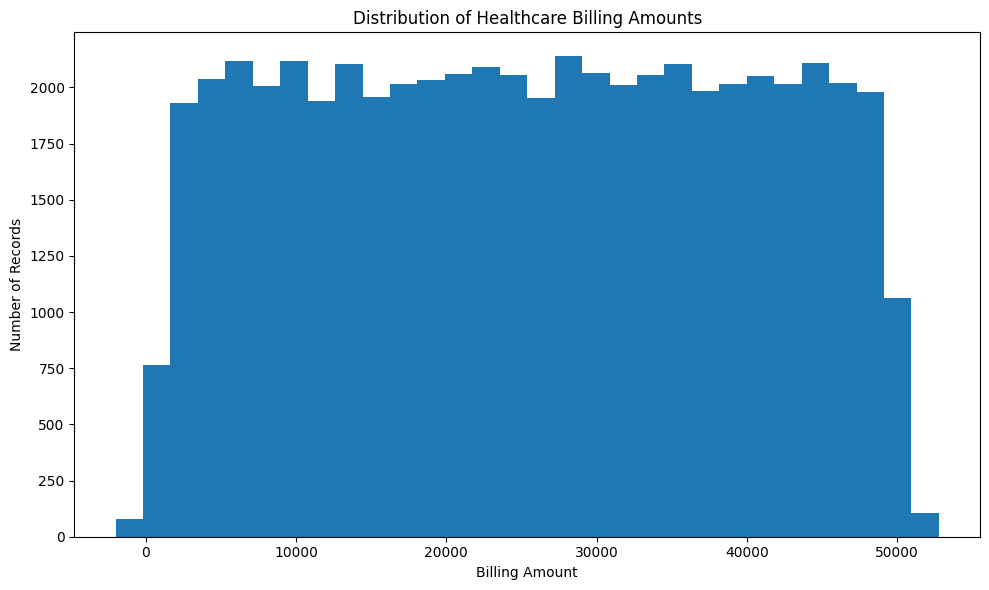

In [119]:
# ==========================================
# STEP 37: BILLING AMOUNT DISTRIBUTION
# ==========================================

query = """
SELECT Billing_Amount
FROM Healthcare_Records;
"""

result = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))

plt.hist(
    result["Billing_Amount"],
    bins=30
)

plt.xlabel("Billing Amount")
plt.ylabel("Number of Records")
plt.title("Distribution of Healthcare Billing Amounts")

plt.tight_layout()
plt.show()

,Medical_Condition,Admission_Type,total_billing
0,Diabetes,Urgent,81474429.35
1,Hypertension,Elective,81316292.67
2,Obesity,Emergency,80043716.31
3,Cancer,Elective,79942117.82
4,Diabetes,Elective,78903370.57
5,Arthritis,Urgent,78796495.26
6,Asthma,Urgent,78520649.82
7,Obesity,Urgent,78514463.64
8,Arthritis,Emergency,78352604.61
9,Arthritis,Elective,78018518.10


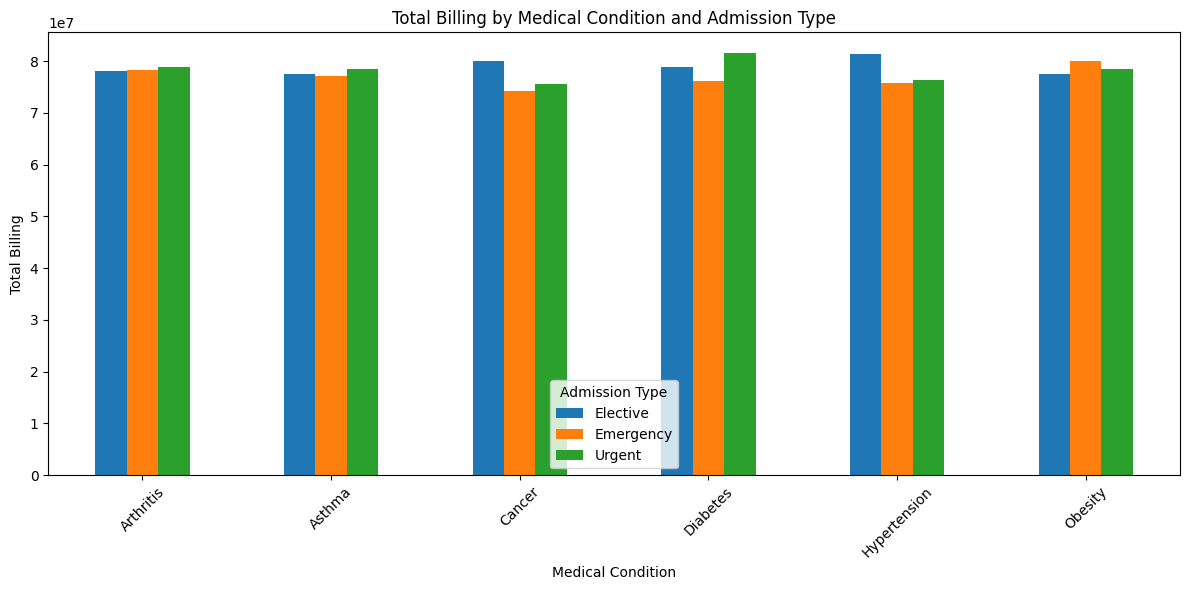

In [120]:
# ==========================================
# STEP 38: BILLING BY CONDITION + ADMISSION
# ==========================================

query = """
SELECT
    Medical_Condition,
    Admission_Type,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Medical_Condition, Admission_Type
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
pivot = result.pivot(
    index="Medical_Condition",
    columns="Admission_Type",
    values="total_billing"
)

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Medical Condition")
plt.ylabel("Total Billing")
plt.title("Total Billing by Medical Condition and Admission Type")
plt.xticks(rotation=45)
plt.legend(title="Admission Type")

plt.tight_layout()
plt.show()

,Medical_Condition,Admission_Type,total_records,average_billing
0,Diabetes,Elective,3031,26032.12
1,Obesity,Urgent,3031,25903.82
2,Asthma,Emergency,2978,25893.70
3,Obesity,Emergency,3100,25820.55
4,Asthma,Urgent,3048,25761.37
5,Obesity,Elective,3015,25687.73
6,Cancer,Elective,3114,25671.84
7,Arthritis,Urgent,3083,25558.38
8,Hypertension,Elective,3182,25555.09
9,Arthritis,Emergency,3073,25497.11


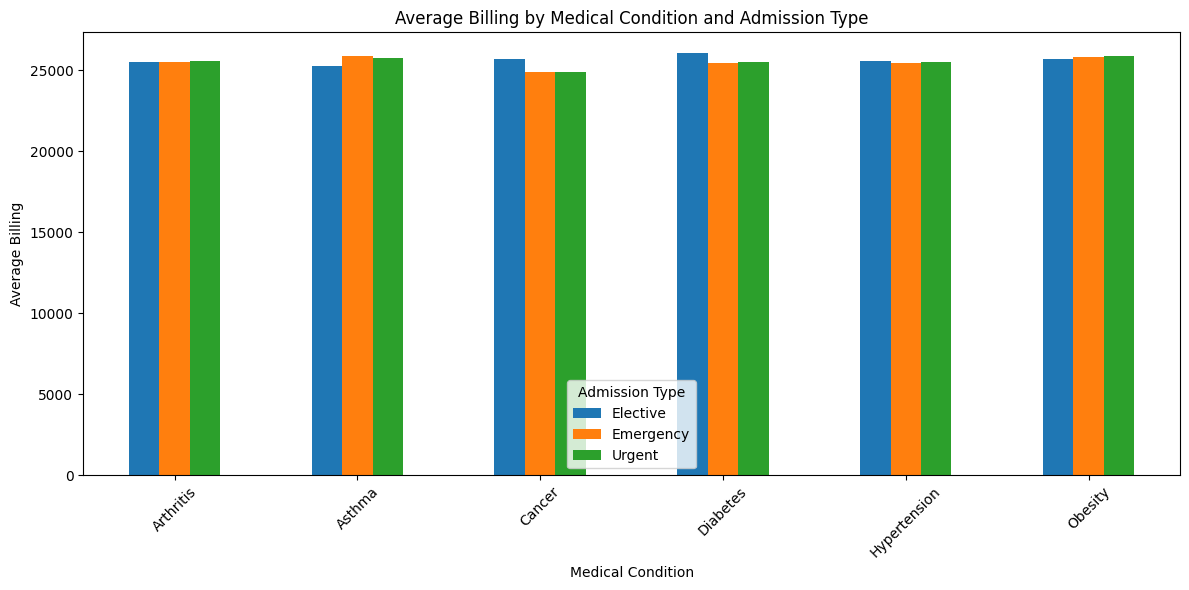

In [121]:
# ==========================================
# STEP 39: AVERAGE BILLING BY CONDITION + ADMISSION
# ==========================================

query = """
SELECT
    Medical_Condition,
    Admission_Type,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing
FROM Healthcare_Records
GROUP BY Medical_Condition, Admission_Type
ORDER BY average_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Visualization
pivot = result.pivot(
    index="Medical_Condition",
    columns="Admission_Type",
    values="average_billing"
)

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Medical Condition")
plt.ylabel("Average Billing")
plt.title("Average Billing by Medical Condition and Admission Type")
plt.xticks(rotation=45)
plt.legend(title="Admission Type")

plt.tight_layout()
plt.show()

In [122]:
# ==========================================
# STEP 40: BILLING BY PROVIDER + CONDITION
# ==========================================

query = """
SELECT
    Insurance_Provider,
    Medical_Condition,
    COUNT(*) AS total_records,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records
GROUP BY Insurance_Provider, Medical_Condition
ORDER BY total_billing DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,Medical_Condition,total_records,average_billing,total_billing
0,Blue Cross,Obesity,1872,26079.99,48821743.56
1,Medicare,Diabetes,1885,25711.12,48465464.44
2,Cigna,Asthma,1890,25622.78,48427056.13
3,Cigna,Obesity,1847,26158.57,48314880.24
4,Aetna,Hypertension,1862,25873.86,48177132.06
5,Cigna,Diabetes,1875,25676.11,48142706.21
6,UnitedHealthcare,Asthma,1854,25793.31,47820788.34
7,Blue Cross,Diabetes,1846,25826.32,47675380.49
8,UnitedHealthcare,Arthritis,1857,25668.94,47667229.57
9,Cigna,Arthritis,1877,25306.74,47500756.67


In [123]:
# ==========================================
# STEP 41: PROVIDER VS OVERALL AVERAGE
# ==========================================

query = """
WITH provider_summary AS (
    SELECT
        Insurance_Provider,
        ROUND(AVG(Billing_Amount), 2) AS average_billing
    FROM Healthcare_Records
    GROUP BY Insurance_Provider
),

overall_average AS (
    SELECT
        ROUND(AVG(Billing_Amount), 2) AS overall_avg
    FROM Healthcare_Records
)

SELECT
    p.Insurance_Provider,
    p.average_billing,
    o.overall_avg,
    ROUND(p.average_billing - o.overall_avg, 2) AS difference_from_overall
FROM provider_summary p
CROSS JOIN overall_average o
ORDER BY difference_from_overall DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Insurance_Provider,average_billing,overall_avg,difference_from_overall
0,Medicare,25628.32,25544.31,84.01
1,Blue Cross,25603.46,25544.31,59.15
2,Aetna,25549.69,25544.31,5.38
3,Cigna,25526.00,25544.31,-18.31
4,UnitedHealthcare,25414.51,25544.31,-129.80


,Insurance_Provider,Medical_Condition,average_billing
0,Aetna,Arthritis,25473.95
1,Aetna,Asthma,25849.52
2,Aetna,Cancer,24943.74
3,Aetna,Diabetes,25549.13
4,Aetna,Hypertension,25873.86
5,Aetna,Obesity,25613.90
6,Blue Cross,Arthritis,25799.66
7,Blue Cross,Asthma,25134.72
8,Blue Cross,Cancer,25062.44
9,Blue Cross,Diabetes,25826.32


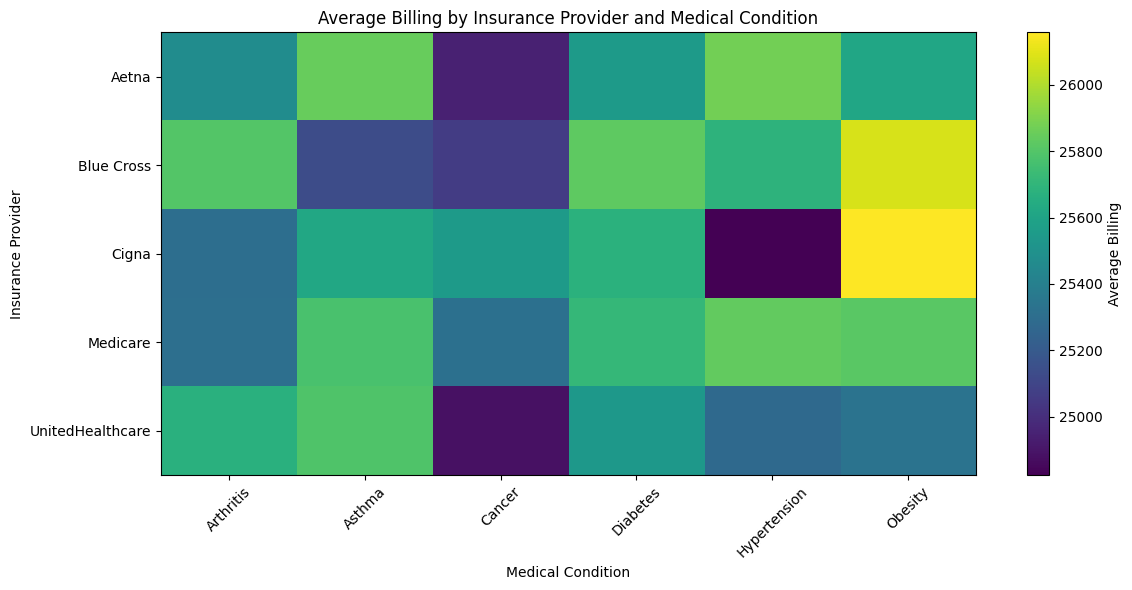

In [124]:
# ==========================================
# STEP 42: PROVIDER × CONDITION HEATMAP
# ==========================================

query = """
SELECT
    Insurance_Provider,
    Medical_Condition,
    ROUND(AVG(Billing_Amount), 2) AS average_billing
FROM Healthcare_Records
GROUP BY Insurance_Provider, Medical_Condition;
"""

result = pd.read_sql_query(query, conn)

display(result)

# Create matrix
pivot = result.pivot(
    index="Insurance_Provider",
    columns="Medical_Condition",
    values="average_billing"
)

# Heatmap
plt.figure(figsize=(12, 6))

plt.imshow(pivot, aspect="auto")

plt.colorbar(label="Average Billing")

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.xlabel("Medical Condition")
plt.ylabel("Insurance Provider")
plt.title("Average Billing by Insurance Provider and Medical Condition")

plt.tight_layout()
plt.show()

In [125]:
# ==========================================
# STEP 43: KEY BUSINESS INSIGHTS
# ==========================================

query = """
SELECT
    ROUND(AVG(Billing_Amount), 2) AS overall_average_billing,
    ROUND(MIN(Billing_Amount), 2) AS minimum_billing,
    ROUND(MAX(Billing_Amount), 2) AS maximum_billing,
    ROUND(SUM(Billing_Amount), 2) AS total_billing
FROM Healthcare_Records;
"""

result = pd.read_sql_query(query, conn)

display(result)

,overall_average_billing,minimum_billing,maximum_billing,total_billing
0,25544.31,-2008.49,52764.28,1.404068e+09


In [126]:
# ==========================================
# STEP 44: FINAL KPI SUMMARY
# ==========================================

query = """
WITH condition_summary AS (
    SELECT
        Medical_Condition,
        ROUND(AVG(Billing_Amount), 2) AS average_billing,
        ROUND(SUM(Billing_Amount), 2) AS total_billing
    FROM Healthcare_Records
    GROUP BY Medical_Condition
),

provider_summary AS (
    SELECT
        Insurance_Provider,
        ROUND(AVG(Billing_Amount), 2) AS average_billing,
        ROUND(SUM(Billing_Amount), 2) AS total_billing
    FROM Healthcare_Records
    GROUP BY Insurance_Provider
)

SELECT
    COUNT(*) AS total_records,
    COUNT(DISTINCT Medical_Condition) AS medical_conditions,
    COUNT(DISTINCT Insurance_Provider) AS insurance_providers,
    ROUND(SUM(Billing_Amount), 2) AS total_billing,
    ROUND(AVG(Billing_Amount), 2) AS average_billing,

    (
        SELECT Medical_Condition
        FROM condition_summary
        ORDER BY total_billing DESC
        LIMIT 1
    ) AS highest_billing_condition,

    (
        SELECT Insurance_Provider
        FROM provider_summary
        ORDER BY total_billing DESC
        LIMIT 1
    ) AS highest_billing_provider,

    (
        SELECT Medical_Condition
        FROM condition_summary
        ORDER BY average_billing DESC
        LIMIT 1
    ) AS highest_average_billing_condition

FROM Healthcare_Records;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_records,medical_conditions,insurance_providers,total_billing,average_billing,highest_billing_condition,highest_billing_provider,highest_average_billing_condition
0,54966,6,5,1.404068e+09,25544.31,Diabetes,Cigna,Obesity


In [ ]:
# FINAL PROJECT CONCLUSIONS

## Healthcare Billing Analysis — Key Findings

1. The dataset contains 54,966 healthcare records covering 6 medical
   conditions and 5 insurance providers.

2. The overall average billing amount is approximately $25,544 per record,
   while the total billing across all records is approximately $1.404 billion.

3. Diabetes generates the highest total billing among the six medical
   conditions.

4. Obesity has the highest average billing per healthcare record, indicating
   that its typical billing amount is relatively high.

5. Cigna has the highest total billing among the five insurance providers.

6. Medical conditions and insurance providers show relatively small
   differences in average billing, while total billing differences are also
   influenced by the number of records.

7. Billing varies across combinations of medical condition, admission type,
   and insurance provider. This demonstrates that analyzing multiple
   business dimensions provides more detailed insights than analyzing
   individual variables separately.

8. The billing distribution shows that healthcare billing amounts are spread
   across a wide range, with some records having substantially higher
   billing amounts.

9. The analysis also identified a negative minimum billing value of
   approximately -$2,008.49. This should be investigated as a potential
   data-quality or data-entry issue.

## Business Takeaway

The analysis demonstrates how SQL and Python can be used together to
transform healthcare billing data into meaningful business insights.
Aggregations, CTEs, window functions, rankings, and visualizations were
used to identify billing patterns across medical conditions, insurance
providers, and admission types.